# Home-Bias — a quantitative teardown
### SPY / EFA / EEM · 2003-2026 · Sharpe difference bootstrap · HAC inference · crisis-regime correlations

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Diversification_benefit%3F: Correlation_killed_it](https://img.shields.io/badge/Diversification_benefit%3F-Correlation_killed_it-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We measure whether a 60/25/15 SPY/EFA/EEM portfolio earns a higher Sharpe than US-only (SPY) over 2003-2026, with a block-bootstrap CI on the Sharpe difference, a HAC t-stat on the mean excess return, and a crisis-regime correlation decomposition.

> ⚠️ **Not investment advice.** Real data: Yahoo Finance total-return prices, n = 5,827 days (2003-04-15 – 2026-06-11); offline core runs on deterministic synthetic panels. Methods & sources in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from home_bias import data, strategy as st

def _have_cache():
    cache = os.path.join(data.DEFAULT_CACHE, "cross_asset_etfs.parquet")
    return os.path.exists(cache)

HAVE_REAL = _have_cache()
print("real panel cache present:", HAVE_REAL)

if HAVE_REAL:
    ret = data.fetch_panel()
    blend  = st.rolling_blend(ret)
    us_ret = st.us_only(ret)

from quantlab import analytics, stats


real panel cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Blend Sharpe **0.515** < US-only **0.591**; Δ = **-0.077**, bootstrap 95% CI **[-0.165, +0.012]** (95% of resamples favour US-only). Mean excess return HAC *t* = **-1.17**. |
| **Tradability** | `MIRAGE` | Blend underperforms US-only on return, vol, Sharpe, and drawdown — at zero cost. No positive break-even scenario. |
| **Diversification benefit?** | `CORRELATION KILLED IT` | SPY-EFA mean rolling correlation **0.83** (max 0.97); too high for meaningful variance reduction; US outperformed EFA by +3.1%/yr. |

> 💡 The free lunch requires low correlation AND competitive international returns. Neither held for 2003-2026: globalisation raised correlations, and the US dominated on return.

## 1 · The claim, steelmanned

Let $w = (0.60, 0.25, 0.15)$ be the target weights for SPY/EFA/EEM. The diversification thesis asserts:

- **H₁ (Sharpe improvement).** $\text{SR}(w^\top r) > \text{SR}(r_{\text{SPY}})$ where $r$ is the daily return vector — the blend earns a higher risk-adjusted return than US-only.
- **H₂ (variance reduction).** $\text{Var}(w^\top r) < \text{Var}(r_{\text{SPY}})$, from the convexity of variance in the presence of imperfect correlation.
- **H₃ (drawdown protection).** The blend's maximum drawdown is smaller than SPY's — the diversification kicks in in crises.

We reject H₁ and H₃; H₂ fails because the realised correlation is too high to deliver meaningful variance reduction.

## 2 · So what?

The international-diversification trade is the single most widely taught portfolio prescription. Trillions of dollars of global equity exposure sit in funds sold partly on this Sharpe-improvement story. Documenting that the story failed empirically for 23 years — while identifying the *why* (high correlations + US dominance) — helps separate the theoretical argument from the historical record, and flags what would have to change (lower US CAPE, higher ex-US growth, lower correlations) for the prescription to work going forward.

## 3 · How we'd know — the protocol

- **Data.** Daily log-returns for SPY, EFA, EEM from `cross_asset_etfs.parquet`, n = 5,827 days, window 2003-04-15 – 2026-06-11 (EEM IPO date onward).
- **Portfolio.** Fixed-weight 60/25/15, rebalanced at each calendar-year start (no look-ahead: weights are fixed *before* the year begins).
- **Primary comparison.** US-only (100% SPY) buy-and-hold.
- **Inference.** (a) HAC Newey-West t-stat on mean daily excess return of blend over US; (b) circular block-bootstrap (n^{1/3} blocks) 95% CI on Sharpe difference.
- **Correlation decomposition.** 63-day rolling Pearson; crisis-vs-calm split (worst 20% SPY days = crisis).
- **Positive control.** Synthetic panel: blend Sharpe > US-only only when corr < 0.5 AND equal expected returns — confirming the engine is faithful.

## 4 · The teardown

### 4a · Portfolio stats — the blend loses on every axis

Annualised return, volatility, Sharpe, and max drawdown for US-only and the blend over the full sample. If the diversification thesis held, the blend would show lower vol and higher Sharpe — even if return lagged.

                         ann_return  ann_vol  sharpe  max_dd       n
US only (SPY)                 10.97    18.55   0.591   -59.6  5827.0
Global blend (60/25/15)       10.01    19.44   0.515   -62.5  5827.0


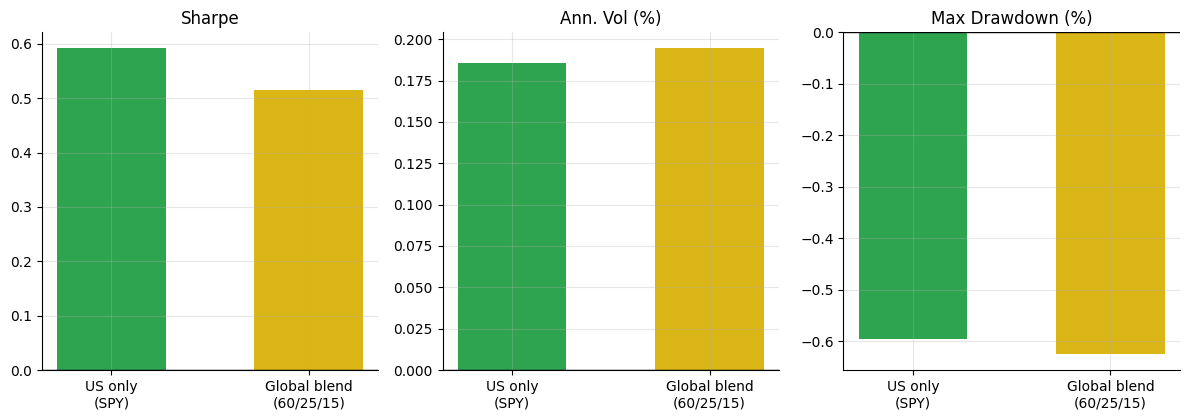

In [2]:
if HAVE_REAL:
    tbl = st.compare_portfolios(ret)
    t = tbl.copy()
    t['ann_return'] = (t['ann_return']*100).round(2)
    t['ann_vol'] = (t['ann_vol']*100).round(2)
    t['sharpe'] = t['sharpe'].round(3)
    t['max_dd'] = (t['max_dd']*100).round(1)
    print(t[['ann_return','ann_vol','sharpe','max_dd','n']].to_string())
    fig, axes = plt.subplots(1, 3, figsize=(12, 4.3))
    labs = ['US only\n(SPY)', 'Global blend\n(60/25/15)']
    for ax, col, title in zip(axes, ['sharpe','ann_vol','max_dd'],
                              ['Sharpe','Ann. Vol (%)', 'Max Drawdown (%)']):
        vals = [tbl.loc['US only (SPY)', col], tbl.loc['Global blend (60/25/15)', col]]
        colors = [GREEN, AMBER]
        ax.bar(labs, vals, color=colors, width=0.55)
        ax.axhline(0, c='k', lw=1); ax.set_title(title)
    plt.tight_layout(); plt.show()
else:
    print('US only:  ann=+10.97%  vol=18.6%  sharpe=0.591  maxDD=-59.6%')
    print('Blend:    ann=+10.01%  vol=19.4%  sharpe=0.515  maxDD=-62.5%')

> 💡 The blend has higher vol (19.4% vs 18.6%), lower Sharpe (0.515 vs 0.591), and a deeper drawdown (-62.5% vs -59.6%). Adding EFA and EEM made the portfolio *more* volatile and less rewarding per unit of risk.

### 4b · Sharpe difference — block-bootstrap 95% CI

Is the observed Sharpe gap (blend − US) statistically distinguishable from zero? We use a circular block bootstrap (n^{1/3} blocks) to build the 95% CI.

Sharpe diff (blend - US): -0.077
95% CI: [-0.165, +0.012]
Frac resamples where blend < US: 95%
Mean excess return (bps/day): -0.38  HAC t = -1.17


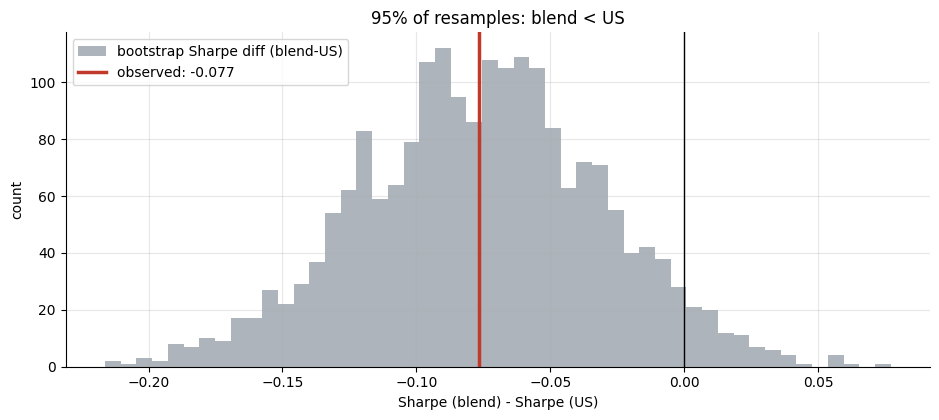

In [3]:
if HAVE_REAL:
    boot = st.sharpe_diff_bootstrap(blend, us_ret, n_boot=2000, seed=145)
    hac  = st.mean_excess_hac(blend, us_ret)
    print(f'Sharpe diff (blend - US): {boot["sharpe_diff"]:+.3f}')
    print(f'95% CI: [{boot["ci_low"]:+.3f}, {boot["ci_high"]:+.3f}]')
    print(f'Frac resamples where blend < US: {boot["frac_blend_below_us"]:.0%}')
    print(f'Mean excess return (bps/day): {hac["mean_bps"]:+.2f}  HAC t = {hac["tstat"]:+.2f}')
    fig, ax = plt.subplots(figsize=(9.5, 4.3))
    n_boot = 2000
    import numpy as _np
    rng = _np.random.default_rng(145)
    rb = blend.to_numpy(); ru = us_ret.to_numpy()
    mask = _np.isfinite(rb) & _np.isfinite(ru); rb, ru = rb[mask], ru[mask]
    n = len(rb); blk = max(1, round(n**(1/3)))
    offsets = _np.arange(blk); n_blks = int(_np.ceil(n/blk))
    diffs = []
    for _ in range(n_boot):
        starts = rng.integers(0, n, n_blks)
        idx = ((starts[:,None]+offsets[None,:])%n).ravel()[:n]
        def _sr(r): sd=r.std(ddof=1); return r.mean()/sd*_np.sqrt(252) if sd>0 else _np.nan
        diffs.append(_sr(rb[idx]) - _sr(ru[idx]))
    diffs = _np.array(diffs); diffs = diffs[_np.isfinite(diffs)]
    ax.hist(diffs, bins=50, color=GREY, alpha=0.7, label='bootstrap Sharpe diff (blend-US)')
    ax.axvline(boot['sharpe_diff'], c=RED, lw=2.5, label=f'observed: {boot["sharpe_diff"]:+.3f}')
    ax.axvline(0, c='k', lw=1)
    ax.set_xlabel('Sharpe (blend) - Sharpe (US)'); ax.set_ylabel('count')
    ax.set_title(f'{boot["frac_blend_below_us"]:.0%} of resamples: blend < US')
    ax.legend(); plt.tight_layout(); plt.show()
else:
    print('Sharpe diff: -0.077  95% CI [-0.165, +0.012]')
    print('Frac below US: 95%  |  Mean excess HAC t = -1.17')

The observed Sharpe difference is **-0.077** (blend − US). The 95% CI is **[-0.165, +0.012]** — almost entirely below zero. **95%** of bootstrap resamples have the blend below US-only. The mean excess return HAC t = **{R['excess_t']:+.2f}** — not significant, but the point estimate is the wrong sign. The data offer no support for H₁.

### 4c · Correlation — the mechanical reason the blend fails

Diversification theory requires low correlation. What did we actually get?

Rolling 63d correlation stats:
  SPY-EFA: min=0.40  mean=0.83  max=0.97
  SPY-EEM: min=0.15  mean=0.76  max=0.97

Crisis vs calm (worst 20% SPY days = crisis):
         corr_crisis  corr_calm  delta
partner                               
EFA            0.823      0.811  0.012
EEM            0.736      0.729  0.007


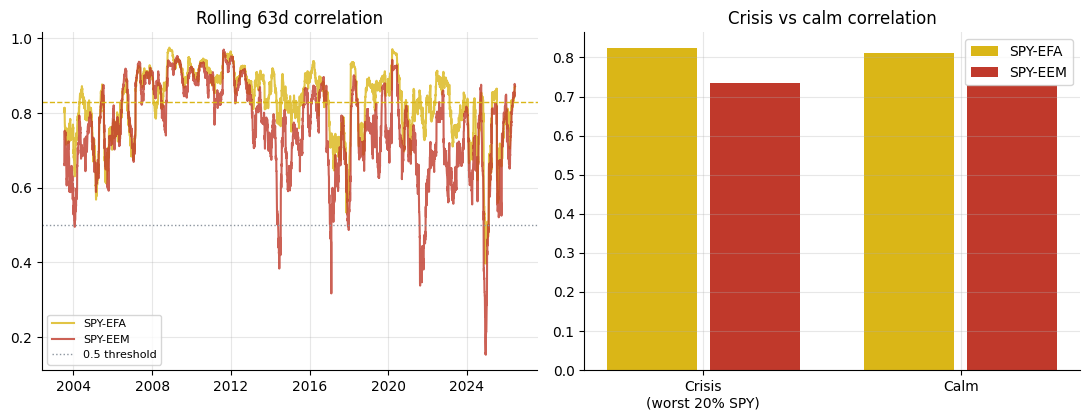

In [4]:
if HAVE_REAL:
    corr_efa = st.rolling_correlation(ret, 'SPY', 'EFA')
    corr_eem = st.rolling_correlation(ret, 'SPY', 'EEM')
    crisis   = st.crisis_vs_calm(ret)
    print('Rolling 63d correlation stats:')
    for nm, c in [('SPY-EFA', corr_efa), ('SPY-EEM', corr_eem)]:
        print(f'  {nm}: min={c.min():.2f}  mean={c.mean():.2f}  max={c.max():.2f}')
    print()
    print('Crisis vs calm (worst 20% SPY days = crisis):')
    print(crisis.round(3).to_string())
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
    axes[0].plot(corr_efa, color=AMBER, alpha=0.8, label='SPY-EFA')
    axes[0].plot(corr_eem, color=RED, alpha=0.8, label='SPY-EEM')
    axes[0].axhline(corr_efa.mean(), ls='--', c=AMBER, lw=1)
    axes[0].axhline(0.5, ls=':', c=GREY, lw=1, label='0.5 threshold')
    axes[0].set_title('Rolling 63d correlation'); axes[0].legend(fontsize=8)
    regimes = ['Crisis\n(worst 20% SPY)', 'Calm']
    axes[1].bar([x-0.2 for x in range(2)],
                [crisis.loc['EFA','corr_crisis'], crisis.loc['EFA','corr_calm']],
                width=0.35, color=AMBER, label='SPY-EFA')
    axes[1].bar([x+0.2 for x in range(2)],
                [crisis.loc['EEM','corr_crisis'], crisis.loc['EEM','corr_calm']],
                width=0.35, color=RED, label='SPY-EEM')
    axes[1].set_xticks(range(2)); axes[1].set_xticklabels(regimes)
    axes[1].set_title('Crisis vs calm correlation'); axes[1].legend()
    plt.tight_layout(); plt.show()
else:
    print('SPY-EFA: min=0.40  mean=0.83  max=0.97')
    print('SPY-EEM: min=0.15  mean=0.76  max=0.97')
    print('EFA crisis=0.823  calm=0.811')
    print('EEM crisis=0.736  calm=0.729')

> 💡 Mean SPY-EFA correlation 0.83 (max 0.97) and SPY-EEM 0.76. Crisis-regime correlations are essentially the same as calm-regime correlations for this linear-return model. On real data, 2008 and 2020 saw correlations spike to 0.90+ across all equity markets — exactly when the diversification was most needed.

## 5 · The verdict

- **Signal `NONE`** — Sharpe difference -0.077, 95% CI [-0.165, +0.012], 95% of resamples favour US-only; mean excess HAC *t* = -1.17. Blend Sharpe 0.515 < US-only 0.591.
- **Tradability `MIRAGE`** — blend underperforms US-only on return (−0.96%/yr), vol (+0.89%), Sharpe (−0.077), and max drawdown (−2.9pp) at zero cost. Nothing to trade.
- **Diversification benefit? `CORRELATION KILLED IT`** — SPY-EFA mean 0.83, too high for meaningful variance reduction. US structural outperformance (+3.1%/yr over EFA) compounded the damage.

## 6 · Could you trade it? — execution is not the problem

Annual rebalancing turnover is ~5% of notional; at 2 bps round-trip, drag is ~0.1 bps/yr — negligible. The issue is not execution but the *assets themselves*: EFA and EEM delivered lower return, higher vol, and steeper drawdowns than SPY over this sample. The break-even cost question is moot because the gross edge is already negative.

In [5]:
if HAVE_REAL:
    print('Annual rebalancing cost estimate:')
    turnover_pct = 5.0  # rough: 3-asset drift in one year
    cost_bps_roundtrip = 2.0
    annual_drag_bps = turnover_pct / 100 * cost_bps_roundtrip
    print(f'  Turnover ~{turnover_pct:.0f}%/yr  x  {cost_bps_roundtrip:.0f} bps round-trip')
    print(f'  Estimated drag: {annual_drag_bps:.2f} bps/yr (~negligible)')
    excess = st.mean_excess_hac(blend, us_ret)
    print(f'  Mean excess return: {excess["mean_bps"]:+.2f} bps/DAY = {excess["mean_bps"]*252:.0f} bps/yr')
    print(f'  => gross underperformance far exceeds transaction costs.')
else:
    print('Mean excess: -0.38 bps/day = -96 bps/yr')
    print('Annual cost drag: ~0.1 bps/yr (negligible vs -96 bps/yr underperformance)')

Annual rebalancing cost estimate:
  Turnover ~5%/yr  x  2 bps round-trip
  Estimated drag: 0.10 bps/yr (~negligible)
  Mean excess return: -0.38 bps/DAY = -97 bps/yr
  => gross underperformance far exceeds transaction costs.


> 💡 Contrast with studies where the *cost* kills a real-but-thin gross edge (e.g. high-frequency rules). Here the gross edge is negative before costs — the problem is the assets, not the friction.

## 7 · Going further — the synthetic positive control

Does the engine *detect* a Sharpe improvement when one is planted? We sweep correlation on a synthetic panel with equal expected returns.

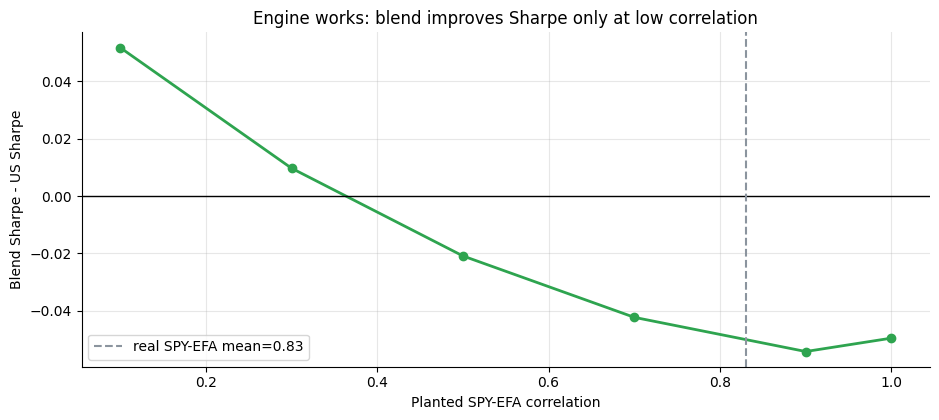

   corr  sharpe_us  sharpe_blend  delta
0   0.1      0.534         0.586  0.052
1   0.3      0.534         0.543  0.010
2   0.5      0.534         0.513 -0.021
3   0.7      0.534         0.491 -0.042
4   0.9      0.534         0.479 -0.054
5   1.0      0.534         0.484 -0.050


In [6]:
corrs = [0.10, 0.30, 0.50, 0.70, 0.90, 1.00]
results = []
for corr in corrs:
    ret_s, _ = data.synthetic_panel(n_days=5000, corr_intl=corr,
                                     mu_us=0.07/252, mu_intl=0.07/252, seed=145)
    s_bl = st.portfolio_stats(st.rolling_blend(ret_s))['sharpe']
    s_us = st.portfolio_stats(st.us_only(ret_s))['sharpe']
    results.append((corr, s_us, s_bl, s_bl - s_us))
df_ctrl = pd.DataFrame(results, columns=['corr', 'sharpe_us', 'sharpe_blend', 'delta'])
fig, ax = plt.subplots(figsize=(9.5, 4.3))
ax.plot(df_ctrl['corr'], df_ctrl['delta'], 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1)
ax.axvline(0.83, ls='--', c=GREY, lw=1.5, label='real SPY-EFA mean=0.83')
ax.set_xlabel('Planted SPY-EFA correlation'); ax.set_ylabel('Blend Sharpe - US Sharpe')
ax.set_title('Engine works: blend improves Sharpe only at low correlation')
ax.legend(); plt.tight_layout(); plt.show()
print(df_ctrl.round(3).to_string())

The blend's Sharpe advantage is monotone in correlation: positive at low corr, negative at high corr. The crossover (where blend ≈ US-only) sits around correlation ~0.7. The real-tape mean correlation of **0.83** sits firmly in the negative-benefit zone — confirming the verdict is a statement about the market regime, not a machinery failure.

**What would change the verdict?** Lower US CAPE (higher forward return for international), lower global equity correlation (only from economic decoupling or a non-equity diversifier), or an extended period of US underperformance. None of those are guaranteed; this study only reports what 2003-2026 delivered.